# WaveNet

## 1 Data

In [2]:
from load_data import load_data

dataset = load_data()

single_step :
   X :
     train :  (7000, 41, 1)
     valid :  (2000, 41, 1)
     test :  (1000, 41, 1)
   Y :
     train :  (7000, 41, 10)
     valid :  (2000, 41, 10)
     test :  (1000, 41, 10)
multi_horizon :
   X :
     train :  (7000, 41, 1)
     valid :  (2000, 41, 1)
     test :  (1000, 41, 1)
   Y :
     train :  (7000, 41, 10)
     valid :  (2000, 41, 10)
     test :  (1000, 41, 10)
sequence :
   X :
     train :  (7000, 41, 1)
     valid :  (2000, 41, 1)
     test :  (1000, 41, 1)
   Y :
     train :  (7000, 41, 10)
     valid :  (2000, 41, 10)
     test :  (1000, 41, 10)


## 2 Model

### 2.1 Layer

In [3]:
None

### 2.2 Model

In [4]:
import tensorflow as tf

def mse_last_time_step(y_true: tf.Tensor, y_pred: tf.Tensor) -> tf.Tensor:
    return tf.keras.metrics.mean_squared_error(y_true[:, -1], y_pred[:, -1])

2023-02-10 13:16:16.214895: I tensorflow/core/platform/cpu_feature_guard.cc:193] This TensorFlow binary is optimized with oneAPI Deep Neural Network Library (oneDNN) to use the following CPU instructions in performance-critical operations:  SSE4.1 SSE4.2 AVX AVX2 FMA
To enable them in other operations, rebuild TensorFlow with the appropriate compiler flags.


In [5]:
model = tf.keras.models.Sequential()
model.add(tf.keras.layers.Input((None, 1)))
for dilation_rate in [1, 2, 4, 8] * 2:
    model.add(tf.keras.layers.Conv1D(filters=20, kernel_size=2, padding="causal", activation="relu", dilation_rate=dilation_rate))
model.add(tf.keras.layers.Conv1D(filters=10, kernel_size=1))
model.compile(optimizer="adam", loss="mse", metrics=mse_last_time_step)
model.summary()

2023-02-10 13:16:18.256850: I tensorflow/stream_executor/cuda/cuda_gpu_executor.cc:980] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero
2023-02-10 13:16:18.329187: I tensorflow/stream_executor/cuda/cuda_gpu_executor.cc:980] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero
2023-02-10 13:16:18.329485: I tensorflow/stream_executor/cuda/cuda_gpu_executor.cc:980] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero
2023-02-10 13:16:18.330288: I tensorflow/core/platform/cpu_feature_guard.cc:193] This TensorFlow binary is optimized with oneAPI Deep Neural Network Library (oneDNN) to use the following CPU instructions in performance-critical operations:  SSE4.1 SSE4.2 AVX AVX2 FMA
To enable them in other operations, rebuild TensorFlow with the appropri

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv1d (Conv1D)             (None, None, 20)          60        
                                                                 
 conv1d_1 (Conv1D)           (None, None, 20)          820       
                                                                 
 conv1d_2 (Conv1D)           (None, None, 20)          820       
                                                                 
 conv1d_3 (Conv1D)           (None, None, 20)          820       
                                                                 
 conv1d_4 (Conv1D)           (None, None, 20)          820       
                                                                 
 conv1d_5 (Conv1D)           (None, None, 20)          820       
                                                                 
 conv1d_6 (Conv1D)           (None, None, 20)          8

## 3 Training

In [6]:
import time
from pathlib import Path

epochs = 100
root_logdir = Path().absolute() / "logs"
early_stopping_cb = tf.keras.callbacks.EarlyStopping(patience=10, restore_best_weights=True)
tensorboard_cb = tf.keras.callbacks.TensorBoard(root_logdir / time.strftime("%Y_%m_%d-%H_%M_%S_rnn_sts"))

%load_ext tensorboard
%tensorboard --logdir=./logs --port=6006

Launching TensorBoard...

In [7]:
history = model.fit(dataset["sequence"]["X"]["train"], dataset["sequence"]["Y"]["train"], validation_data=(dataset["sequence"]["X"]["valid"], dataset["sequence"]["Y"]["valid"]), epochs=epochs, callbacks=[early_stopping_cb, tensorboard_cb])

Epoch 1/100


2023-02-10 13:19:19.652955: I tensorflow/stream_executor/cuda/cuda_dnn.cc:384] Loaded cuDNN version 8401
2023-02-10 13:19:20.402933: I tensorflow/core/platform/default/subprocess.cc:304] Start cannot spawn child process: No such file or directory
2023-02-10 13:19:20.403500: I tensorflow/core/platform/default/subprocess.cc:304] Start cannot spawn child process: No such file or directory
2023-02-10 13:19:20.403517: W tensorflow/stream_executor/gpu/asm_compiler.cc:80] Couldn't get ptxas version string: INTERNAL: Couldn't invoke ptxas --version
2023-02-10 13:19:20.404082: I tensorflow/core/platform/default/subprocess.cc:304] Start cannot spawn child process: No such file or directory
2023-02-10 13:19:20.404141: W tensorflow/stream_executor/gpu/redzone_allocator.cc:314] INTERNAL: Failed to launch ptxas
Relying on driver to perform ptx compilation. 
Modify $PATH to customize ptxas location.
This message will be only logged once.


219/219 [==============================] - 6s 12ms/step - loss: 0.0492 - mse_last_time_step: 0.0409 - val_loss: 0.0229 - val_mse_last_time_step: 0.0169
Epoch 2/100
219/219 [==============================] - 2s 7ms/step - loss: 0.0179 - mse_last_time_step: 0.0125 - val_loss: 0.0142 - val_mse_last_time_step: 0.0096
Epoch 3/100
219/219 [==============================] - 2s 7ms/step - loss: 0.0130 - mse_last_time_step: 0.0086 - val_loss: 0.0115 - val_mse_last_time_step: 0.0077
Epoch 4/100
219/219 [==============================] - 2s 7ms/step - loss: 0.0111 - mse_last_time_step: 0.0072 - val_loss: 0.0111 - val_mse_last_time_step: 0.0075
Epoch 5/100
219/219 [==============================] - 1s 6ms/step - loss: 0.0103 - mse_last_time_step: 0.0066 - val_loss: 0.0098 - val_mse_last_time_step: 0.0062
Epoch 6/100
219/219 [==============================] - 1s 6ms/step - loss: 0.0097 - mse_last_time_step: 0.0060 - val_loss: 0.0093 - val_mse_last_time_step: 0.0057
Epoch 7/100
219/219 [============

In [8]:
# Save model
dir_models = Path() / "models"
model.save(dir_models / "model_wavenet")

INFO:tensorflow:Assets written to: models/model_lstm/assets


INFO:tensorflow:Assets written to: models/model_lstm/assets


## 4 Evaluation

In [9]:
import numpy as np

i_ts = 1
x = dataset["sequence"]["X"]["test"][i_ts, :]
y_true = dataset["sequence"]["Y"]["test"][i_ts][-1, :]
y_pred = model.predict(x[np.newaxis, :, :])[0, -1]

1/1 [==============================] - 0s 415ms/step


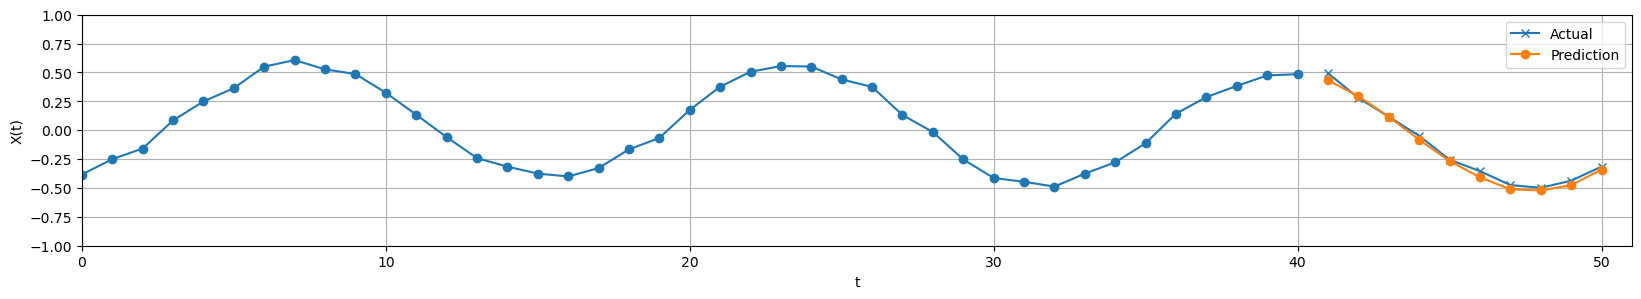

In [10]:
from plot import plot

plot(series=x[:, 0], y_true=y_true, y_pred=y_pred)